# Day 3 — RNNs & LSTMs for Sequential Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train_df = pd.read_csv("/content/mitbih_train.csv")
test_df = pd.read_csv("/content/mitbih_test.csv")

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87553, 188)
Test shape: (21891, 188)


In [ ]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (87553, 187)
y_train: (87553,)
X_test: (21891, 187)
y_test: (21891,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (70042, 187)
y_train: (70042,)
X_val: (17511, 187)
y_val: (17511,)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (70042, 187, 1)
X_val: (17511, 187, 1)
X_test: (21891, 187, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(64, input_shape=(187, 1)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(5, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Architecture

The LSTM model consists of four layers:

- **LSTM Layer:** 64 units to learn sequential patterns from the ECG signals.
- **Dropout Layer:** 30% dropout to reduce overfitting.
- **Dense Layer:** 32 neurons with ReLU activation.
- **Output Layer:** 5 neurons with softmax activation for the five ECG heartbeat classes.

### Model Parameters

- **Total parameters:** 19,141 (74.77 KB)
- **Trainable parameters:** 19,141 (74.77 KB)
- **Non-trainable parameters:** 0

All model parameters are trainable.

In [ ]:
import time

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

lstm_time = time.time() - start_time

print(f"Training Time: {lstm_time:.2f} seconds")

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8270 - loss: 0.6931 - val_accuracy: 0.8277 - val_loss: 0.6528
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8280 - loss: 0.6563 - val_accuracy: 0.8281 - val_loss: 0.6461
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8281 - loss: 0.6496 - val_accuracy: 0.8272 - val_loss: 0.6440
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8278 - loss: 0.6383 - val_accuracy: 0.8278 - val_loss: 0.5982
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8282 - loss: 0.6565 - val_accuracy: 0.8275 - val_loss: 0.6545
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8278 - loss: 0.6556 - val_accuracy: 0.8285 - val_loss: 0.6492
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8290 - loss: 0.6309 - val_accuracy: 0.8295 - val_loss: 0.5581
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8522 - loss: 0.5063 - val_acc

## LSTM Training Results

The LSTM model was trained for 10 epochs using a batch size of 128.

### Results

- **Training Accuracy:** 90.12%
- **Validation Accuracy:** 89.65%
- **Validation Loss:** 0.3771
- **Training Time:** 79.61 seconds

The model showed steady improvement during training. Training and validation accuracy remained close to each other, reaching 90.12% and 89.65%, respectively, by the final epoch.

The relatively small difference between training and validation accuracy indicates that the model generalizes well without severe overfitting.

In [ ]:
test_loss, test_accuracy = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8944 - loss: 0.3882
Test Loss: 0.3882
Test Accuracy: 0.8944


## LSTM Test Evaluation

The trained LSTM model was evaluated on the unseen test set.

### Results

- **Test Accuracy:** 89.44%
- **Test Loss:** 0.3882
- **Validation Accuracy:** 89.65%
- **Training Time:** 79.61 seconds

The model achieved a test accuracy of 89.44%, which is very close to the validation accuracy of 89.65%. This small difference indicates that the model generalizes well to unseen ECG heartbeat data.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred_probs = lstm_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)



685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95     18117
         1.0       0.23      0.06      0.09       556
         2.0       0.66      0.43      0.52      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.71      0.83      0.76      1608

    accuracy                           0.89     21891
   macro avg       0.50      0.46      0.46     21891
weighted avg       0.87      0.89      0.88     21891



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


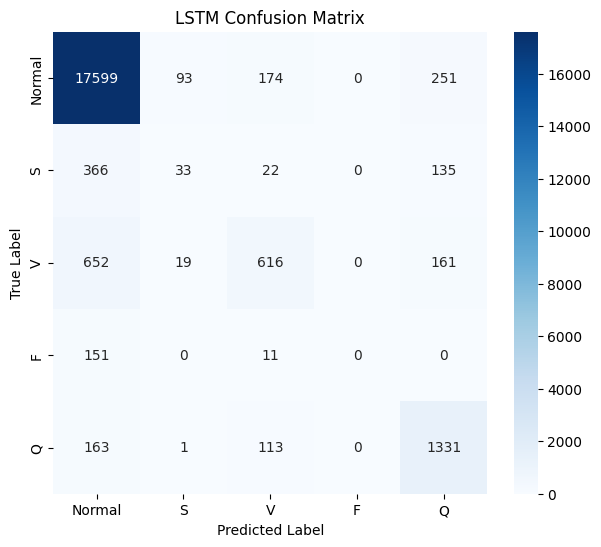

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "S", "V", "F", "Q"],
    yticklabels=["Normal", "S", "V", "F", "Q"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

rnn_model = Sequential([
    SimpleRNN(64, input_shape=(187, 1)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(5, activation="softmax")
])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,469 (25.27 KB)

 Trainable params: 6,469 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_time = time.time()

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

rnn_time = time.time() - start_time

print(f"RNN Training Time: {rnn_time:.2f} seconds")

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8449 - loss: 0.5770 - val_accuracy: 0.8680 - val_loss: 0.4610
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8636 - loss: 0.4996 - val_accuracy: 0.8277 - val_loss: 0.6712
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8277 - loss: 0.6673 - val_accuracy: 0.8277 - val_loss: 0.6663
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8277 - loss: 0.6628 - val_accuracy: 0.8277 - val_loss: 0.6595
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8277 - loss: 0.6616 - val_accuracy: 0.8277 - val_loss: 0.6604
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8277 - loss: 0.6604 - val_accuracy: 0.8277 - val_loss: 0.6601
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8277 - loss: 0.6593 - val_accuracy: 0.8277 - val_loss: 0.6567
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8277 - loss: 0.6590 - val_acc

In [ ]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"RNN Test Loss: {rnn_loss:.4f}")
print(f"RNN Test Accuracy: {rnn_accuracy:.4f}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8276 - loss: 0.6595
RNN Test Loss: 0.6595
RNN Test Accuracy: 0.8276


## LSTM vs Plain RNN

To compare the LSTM with a simpler sequential model, a Plain RNN using the same dataset, data split, batch size, and number of epochs was trained.

| Model | Test Accuracy | Test Loss | Training Time |
|---|---:|---:|---:|
| Plain RNN | 82.76% | 0.6595 | 83.64 seconds |
| **LSTM** | **89.44%** | **0.3882** | **79.61 seconds** |

The LSTM achieved a test accuracy of **89.44%**, outperforming the Plain RNN by **6.68 percentage points**.

The LSTM also achieved a lower test loss (0.3882 vs. 0.6595). In this experiment, the LSTM required slightly less training time than the Plain RNN.

Overall, the LSTM performed better than the Plain RNN for ECG heartbeat classification, suggesting that its ability to capture longer-term dependencies in sequential data was beneficial for this task.

## Why Order-Awareness Helped

ECG heartbeat signals are **sequential data**, where the order of the signal values matters. Each heartbeat is represented by a sequence of 187 values, and patterns such as peaks, changes, and wave shapes depend on how these values occur over time.

The LSTM was able to process the ECG values **in their original order** and learn temporal patterns across the sequence. This helped it distinguish between different heartbeat classes more effectively.

The results support this idea:

- **Plain RNN:** 82.76% test accuracy
- **LSTM:** **89.44% test accuracy**
- **Improvement:** **6.68 percentage points**

The LSTM's ability to remember information from earlier parts of the ECG sequence was particularly useful for recognizing patterns that depend on relationships between different points in time.

Therefore, preserving the **sequential order** of the ECG signal helped the LSTM learn meaningful heartbeat patterns, leading to better performance than the simpler RNN.

In [27]:

!pip freeze > requirements.txt